In [12]:
from azure.storage.blob import BlobServiceClient
import pandas as pd
import numpy as np 
import io, os
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt 

In [13]:
# Connect to Azure Blob

os.environ["AZURE_CONNECTION_STRING"] = "ENTER_YOUR_CONNECTION_STRING_HERE"

connection_str = os.getenv("AZURE_CONNECTION_STRING")
client = BlobServiceClient.from_connection_string(connection_str) 
container = client.get_container_client("flight-data") 
 
def load_blob_csv(filename, sep=","):
    blob = container.get_blob_client(filename)
    data = blob.download_blob().readall()
    return pd.read_csv(io.BytesIO(data), sep=sep)

#load data set

df = load_blob_csv("processed/flights_clean.csv")

print(df.shape)

(300261, 15)


In [14]:
# convert Num_stops to numeric values
stop_map = {"non-stop": 0, "1-stop": 1, "2+-stop": 2} 
df["num_stops"] = df["stop"].map(stop_map)

In [5]:
df.head(1)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,duration_min,dep_hour,arr_hour,num_stops
0,2025-02-11,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,Economy,130,18,21,0


In [15]:
# select only key numeric features for clustering 
cluster_features = ["price", "duration_min", "num_stops", "dep_hour"]

In [7]:
X_cluster = df[cluster_features].dropna()

In [16]:
# Standardise all features same scale 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X_cluster)

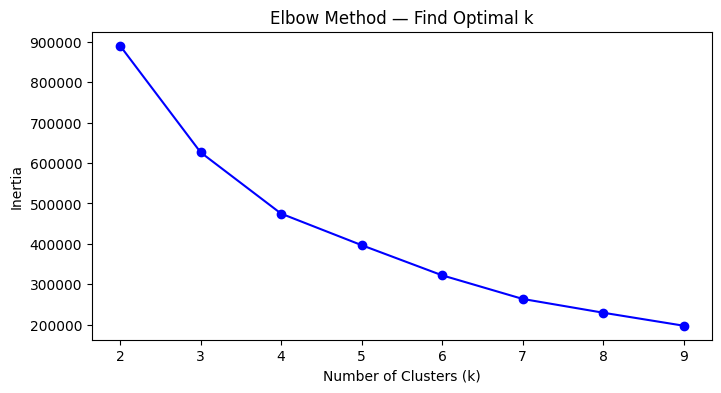

In [17]:
# Find optimal number of clusters using Elbow Method 

inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, "bo-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Find Optimal k")
plt.savefig("../reports/elbow_plot.png", dpi=150)
plt.show()

In [19]:
# Apply K-Means with k=4 (likely showing: budget/economy/premium/luxury)  
km_final = KMeans(n_clusters=4, random_state=42, n_init=10) 
df["cluster"] = km_final.fit_predict(X_scaled)

In [21]:
# Describe each cluster 
cluster_summary = df.groupby("cluster")[["price", "duration_min", "num_stops"]].mean() 
print(cluster_summary)

                price  duration_min  num_stops
cluster                                       
0         7148.489272    550.838646   1.067043
1        55846.708752    879.261292   1.013052
2         8549.646338   1155.061559   1.066297
3         9368.465237    131.403424   0.000000


In [22]:
# Name the clusters based on average price 
labels = {3: "Budget", 0: "Standard Economy", 2: "Long Haul Economy", 2: "Premium" }

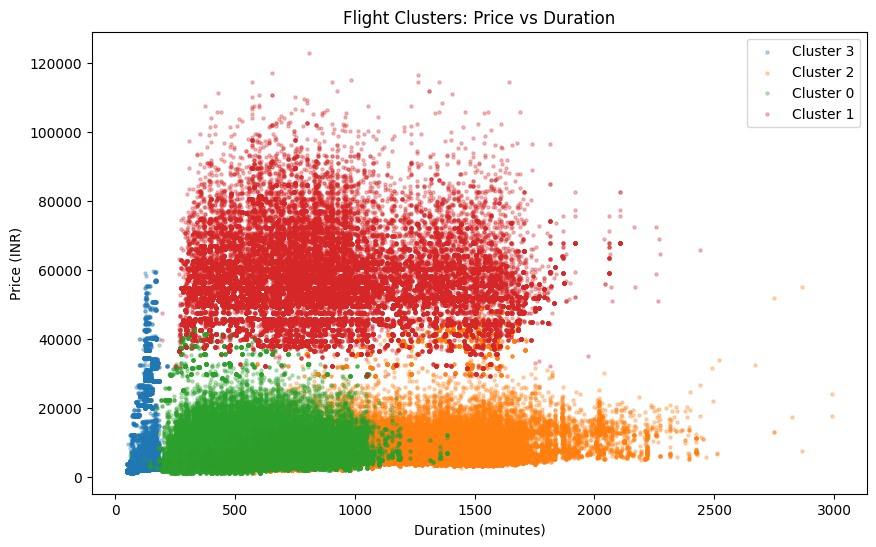

In [23]:
# Visualise clusters 

plt.figure(figsize=(10, 6))

for c in df["cluster"].unique():
    sub = df[df["cluster"] == c]
    plt.scatter(
        sub["duration_min"],
        sub["price"],
        alpha=0.3,
        label=f"Cluster {c}",
        s=5
    )

plt.xlabel("Duration (minutes)")
plt.ylabel("Price (INR)")
plt.title("Flight Clusters: Price vs Duration")
plt.legend()

plt.savefig("../reports/clusters.png", dpi=150)
plt.show()